Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


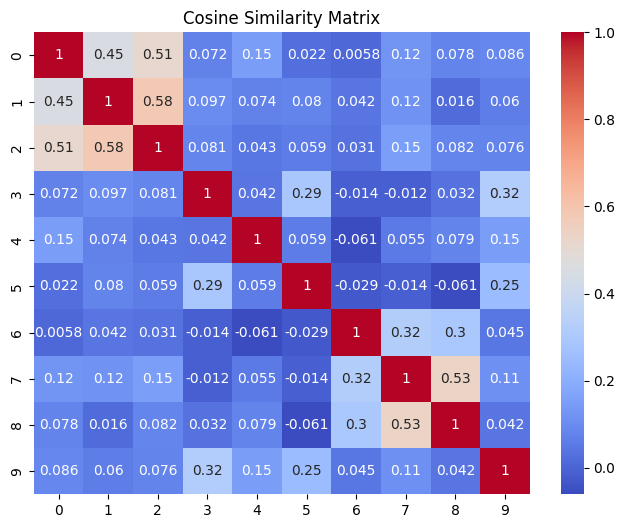

Top 2 similar sentences:
The bowler took three wickets in the over → Score: 0.9856
India won the cricket match by 5 runs → Score: 0.5856


In [3]:
# Install library
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 10 sentences (3 topics)
sentences = [
    # Cricket
    "Virat Kohli scored a century in the match",
    "The bowler took three wickets in the over",
    "India won the cricket match by 5 runs",

    # Cooking
    "I cooked pasta with fresh vegetables",
    "Baking a cake requires precise measurements",
    "The recipe includes spices and herbs",

    # Cybersecurity
    "Strong passwords protect your online accounts",
    "Cyber attacks can compromise sensitive data",
    "Encryption ensures data security",

    # Extra sentence
    "Cooking at home is healthier than eating outside"
]

# Generate embeddings
embeddings = model.encode(sentences)

# Cosine similarity matrix
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

# Query
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Compute similarity with sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = np.argsort(similarities)[-2:][::-1]

print("Top 2 similar sentences:")
for idx in top_indices:
    print(f"{sentences[idx]} → Score: {similarities[idx]:.4f}")